<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Multiclass%20Classification/Obese_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sujithmandala/obesity-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'obesity-classification-dataset' dataset.
Path to dataset files: /kaggle/input/obesity-classification-dataset


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/obesity-classification-dataset/Obesity Classification.csv")
df.head()

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese


In [4]:
df.describe()

,ID,Age,Height,Weight,BMI
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,56.046296,46.555556,166.574074,59.490741,20.549074
std,31.917939,24.720620,27.873615,28.856233,7.583818
min,1.000000,11.000000,120.000000,10.000000,3.900000
25%,28.750000,27.000000,140.000000,35.000000,16.700000
50%,56.500000,42.500000,175.000000,55.000000,21.200000
75%,83.250000,59.250000,190.000000,85.000000,26.100000
max,110.000000,112.000000,210.000000,120.000000,37.200000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      108 non-null    int64  
 1   Age     108 non-null    int64  
 2   Gender  108 non-null    object 
 3   Height  108 non-null    int64  
 4   Weight  108 non-null    int64  
 5   BMI     108 non-null    float64
 6   Label   108 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 6.0+ KB


In [7]:
df['Label'].unique()

array(['Normal Weight', 'Overweight', 'Underweight', 'Obese'],
      dtype=object)

In [10]:
features = df.drop(columns=['ID','Label'])
features

,Age,Gender,Height,Weight,BMI
0,25,Male,175,80,25.3
1,30,Female,160,60,22.5
2,35,Male,180,90,27.3
3,40,Female,150,50,20.0
4,45,Male,190,100,31.2
...,...,...,...,...,...
103,11,Male,175,10,3.9
104,16,Female,160,10,3.9
105,21,Male,180,15,5.6
106,26,Female,150,15,5.6


In [11]:
labels = pd.DataFrame(df, columns=['Label'])
labels

,Label
0,Normal Weight
1,Normal Weight
2,Overweight
3,Underweight
4,Obese
...,...
103,Underweight
104,Underweight
105,Underweight
106,Underweight


In [14]:
y = labels.values.ravel()
y[:5]

array(['Normal Weight', 'Normal Weight', 'Overweight', 'Underweight',
       'Obese'], dtype=object)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2)
len(X_train), len(X_test)

(86, 22)

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_cols = ['Age','Height','Weight','BMI']
categorical_cols=['Gender']

In [25]:
Numerical_pipe = Pipeline(steps=[
    ('scale', StandardScaler())
])
Categorical_pipe = Pipeline(steps=[
    ('encode', OneHotEncoder())
])

In [26]:
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', Numerical_pipe, numerical_cols),
        ('categoric', Categorical_pipe, categorical_cols)
    ])

model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', RandomForestClassifier())])

In [27]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'BMI']),
                                                 ('categoric',
                                                  Pipeline(steps=[('encode',
                                                                   OneHotEncoder())]),
                                                  ['Gender'])])),
                ('classifier', RandomForestClassifier())])

In [28]:
model_pipeline.score(X_test, y_test)

1.0

               precision    recall  f1-score   support

Normal Weight       1.00      1.00      1.00         5
        Obese       1.00      1.00      1.00         2
   Overweight       1.00      1.00      1.00         5
  Underweight       1.00      1.00      1.00        10

     accuracy                           1.00        22
    macro avg       1.00      1.00      1.00        22
 weighted avg       1.00      1.00      1.00        22



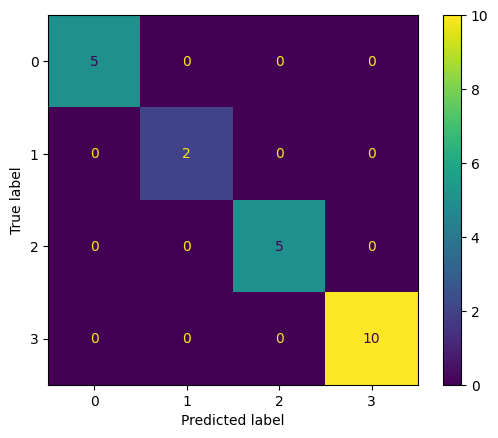

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

pred = model_pipeline.predict(X_test)
cr = classification_report(y_test, pred)
cm = confusion_matrix(y_test, pred)
print(cr)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [30]:
model_pipeline.classes_

array(['Normal Weight', 'Obese', 'Overweight', 'Underweight'],
      dtype=object)